In [4]:
import numpy as np
import pandas as pd

In [5]:
df=pd.read_csv("customer_segmentation.csv")

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
df.dropna(inplace=True)     # Removing the missing values

In [10]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [11]:
df['Dt_Customer']=pd.to_datetime(df["Dt_Customer"],dayfirst=True )

In [12]:
df["Age"]=2026-df['Year_Birth']   

In [13]:
df['Total_children']=df['Kidhome']+df['Teenhome']

In [14]:
df['Total_spend']=df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

In [15]:
currentDate = pd.to_datetime("2026-10-08")
df['Customer_since']=(currentDate-df['Dt_Customer']).dt.days

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_children,Total_spend,Customer_since
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,3,11,1,69,0,1617,5147
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,3,11,0,72,2,27,4597
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,3,11,0,61,0,776,4796
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,3,11,0,42,1,53,4623
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,3,11,0,45,1,422,4645


In [20]:
features=['Age','Income','Total_spend', 'NumWebPurchases', 'NumStorePurchases','Recency','NumWebVisitsMonth','Customer_since']

In [21]:
df_train=df[features]

In [22]:
df_train.head(5)

,Age,Income,Total_spend,NumWebPurchases,NumStorePurchases,Recency,NumWebVisitsMonth,Customer_since
0,69,58138.0,1617,8,4,58,7,5147
1,72,46344.0,27,1,2,38,5,4597
2,61,71613.0,776,8,10,26,4,4796
3,42,26646.0,53,2,4,26,6,4623
4,45,58293.0,422,5,6,94,5,4645


In [23]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
scaled=sc.fit_transform(df_train)

In [28]:
#Applying kmeans clustering
from sklearn.cluster import KMeans

In [ ]:
k_n=range(2,10)
ssc=[]

for i in k_n:
    km=KMeans(n_clusters=i)
    km.fit(scaled)
    ssc.append(km.inertia_)

[np.float64(0.2830677250361405),
 np.float64(0.17970303022011333),
 np.float64(0.16483190338273115),
 np.float64(0.153201482382542),
 np.float64(0.14773101925696472),
 np.float64(0.15240488706209104),
 np.float64(0.15076842472430294),
 np.float64(0.14045487029886553)]

In [30]:
ssc

[12419.216909133262,
 11356.723578426947,
 10121.260532979768,
 9622.590166832482,
 9085.977676096838,
 8574.275151857524,
 8248.98779226603,
 8004.662618716732]

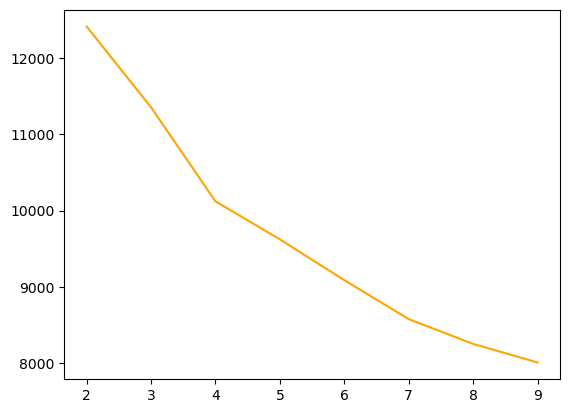

In [31]:
import matplotlib.pyplot as plt
plt.plot(k_n,ssc,color='orange')
plt.show()

In [33]:
k_means=KMeans(n_clusters=4)
k_means.fit(scaled)

KMeans(n_clusters=4)

In [34]:
k_means.labels_

array([1, 3, 1, ..., 2, 2, 0], dtype=int32)

In [35]:
df_train["Clusters"]=(k_means.labels_)

C:\Users\User\AppData\Local\Temp\ipykernel_12888\2842199481.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train["Clusters"]=(k_means.labels_)


In [36]:
df_train.head(5)

,Age,Income,Total_spend,NumWebPurchases,NumStorePurchases,Recency,NumWebVisitsMonth,Customer_since,Clusters
0,69,58138.0,1617,8,4,58,7,5147,1
1,72,46344.0,27,1,2,38,5,4597,3
2,61,71613.0,776,8,10,26,4,4796,1
3,42,26646.0,53,2,4,26,6,4623,3
4,45,58293.0,422,5,6,94,5,4645,3


In [38]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(scaled)

In [39]:
df_train['PCA1'],df_train['PCA2']=pca_data[:,0],pca_data[:,1]

C:\Users\User\AppData\Local\Temp\ipykernel_12888\1560774053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['PCA1'],df_train['PCA2']=pca_data[:,0],pca_data[:,1]
C:\Users\User\AppData\Local\Temp\ipykernel_12888\1560774053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['PCA1'],df_train['PCA2']=pca_data[:,0],pca_data[:,1]


In [40]:
df_train.head()

,Age,Income,Total_spend,NumWebPurchases,NumStorePurchases,Recency,NumWebVisitsMonth,Customer_since,Clusters,PCA1,PCA2
0,69,58138.0,1617,8,4,58,7,5147,1,1.187690,2.045176
1,72,46344.0,27,1,2,38,5,4597,3,-1.399134,-1.616527
2,61,71613.0,776,8,10,26,4,4796,1,1.873884,0.143160
3,42,26646.0,53,2,4,26,6,4623,3,-1.832613,-0.853036
4,45,58293.0,422,5,6,94,5,4645,3,-0.021754,-0.582447


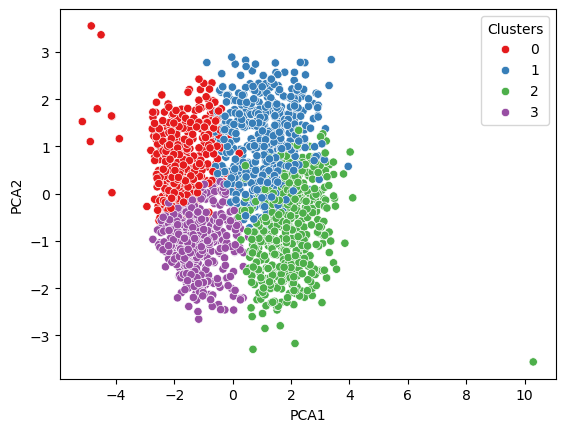

In [42]:
import seaborn as sns
sns.scatterplot(x='PCA1',y='PCA2',data=df_train,hue='Clusters',palette='Set1')
plt.show()

In [46]:

from sklearn.metrics import silhouette_score
# Evaluate existing K-Means model
silhouette = silhouette_score(scaled, k_means.labels_)


print("Silhouette Score:",silhouette)


Silhouette Score: 0.16479877757672626


In [ ]:
from sklearn.mixture import GaussianMixture
bic_scores = []

for k in range(2, 10):
    gm = GaussianMixture(n_components=k, random_state=42)
    gm.fit(scaled)
    bic_scores.append(gm.bic(scaled))

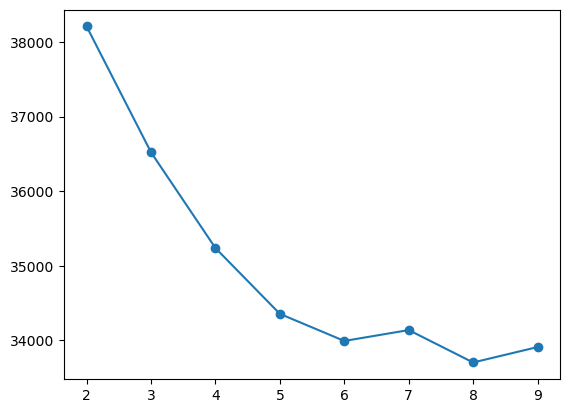

In [48]:
plt.plot(range(2, 10), bic_scores, marker='o')
plt.show()

In [49]:
gmm = GaussianMixture(n_components=8, random_state=42)
gmm.fit(scaled)

gmm_labels = gmm.predict(scaled)

In [50]:
gmm_score = silhouette_score(scaled, gmm_labels)
print("GMM Silhouette Score:", gmm_score)

GMM Silhouette Score: 0.070199551071711
